In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import scipy
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.cluster import k_means, KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

In [2]:
import sys

sys.path.append("../src")

In [3]:
from core import SITE_NAMES
from calls import plot_call_features, compute_features

color_for_groups = {0: 'orange', 1: 'lightskyblue'}
label_for_groups = {0: 'High-frequency', 1: 'Low-frequency'}

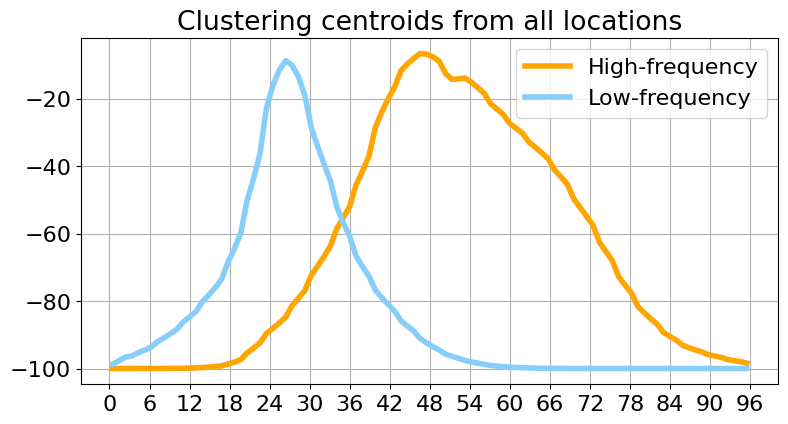

In [7]:
site_key = 'all_locations'
output_dir = Path(f'../data/generated_welch/{site_key}')
if not(output_dir.is_dir()):
    output_dir.mkdir(parents=True)
output_file_type = 'top1_inbouts_welch_signals'

welch_data = pd.read_csv(output_dir / f'2022_{site_key}_{output_file_type}.csv', index_col=0, low_memory=False)
welch_data.columns.name = 'Frequency (Hz)'

k = 2
state = 1500
kmean_welch = KMeans(n_clusters=k, n_init=10, random_state=state).fit(welch_data)
plt.figure(figsize=(9, 4.5))
plt.rcParams.update({'font.size':16})
plt.title(f'Clustering centroids from all locations')
for i in range(k):
    plt.plot(kmean_welch.cluster_centers_[i], label=f'{label_for_groups[i]}', color=color_for_groups[i], alpha=1, linewidth=4)
plt.xticks(np.linspace(0, welch_data.shape[1], 17)-0.5, np.linspace(0, 96, 17).astype(int), rotation=0)
plt.grid(which='both')
plt.legend(loc='upper right', fontsize=16)
plt.show()

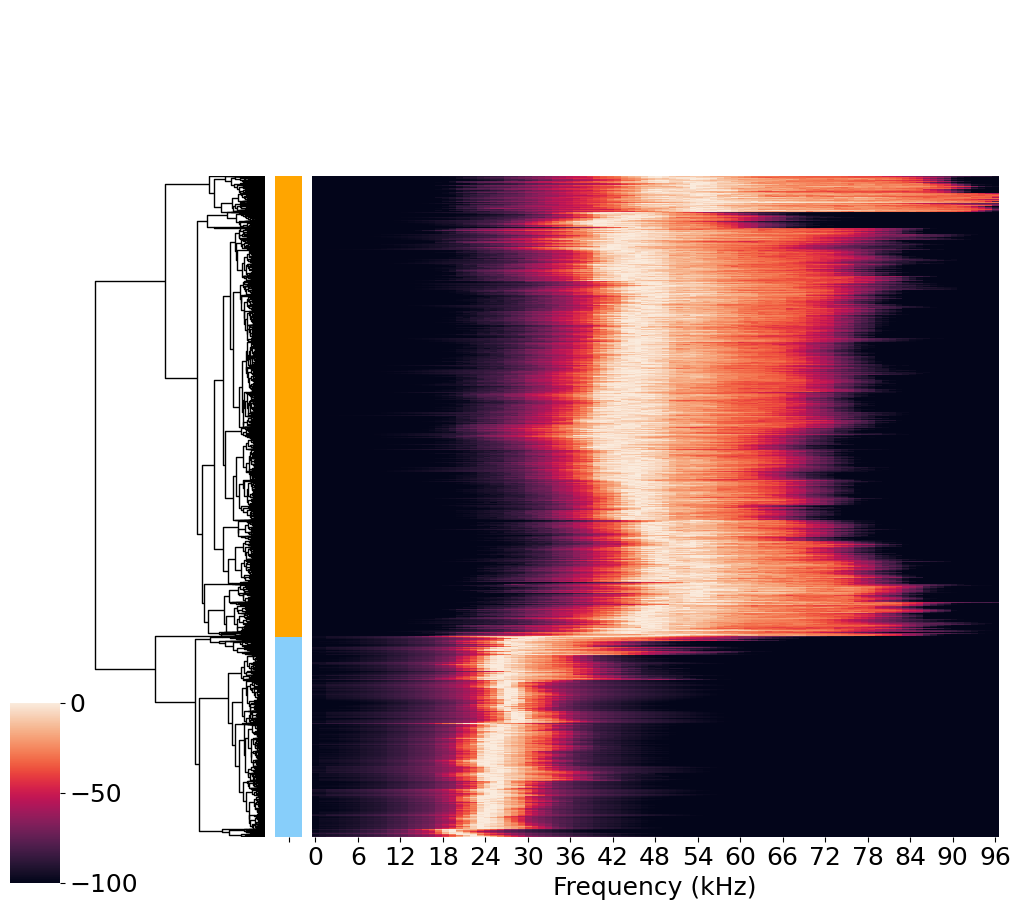

In [8]:
groups = pd.Series(kmean_welch.labels_)
groups_to_labels = groups.map(label_for_groups)
groups_to_colors = groups.map(color_for_groups)
desired_xlabels = np.arange(0, welch_data.shape[1], 6)
desired_xticks = (desired_xlabels * ((welch_data.shape[1]-1)/96))+0.5

plt.rcParams.update({'font.size':18})
g = sns.clustermap(welch_data, figsize=(10, 10), col_cluster=False, row_colors=groups_to_colors, cbar_pos=(-0.05, 0.1, 0.05, 0.18), yticklabels=False, tree_kws=dict(linewidths=1, colors='k'))
ax = g.ax_heatmap
ax.set_ylabel('')
ax.set_xticks(desired_xticks, desired_xlabels, rotation=0)
ax.set_xlabel('Frequency (kHz)')
plt.show()